In [366]:
using PyPlot
using FFTW, Interpolations
using JLD2
using Tullio
using PyCall
using KadanoffBaym, LinearAlgebra, BlockArrays
using LaTeXStrings
using FFTW, Interpolations
using Tullio
using JLD2
mpl_ticker = pyimport("matplotlib.ticker")
### Parameters of the figure 
rc("text", usetex=true)
rc("font", family="serif")
#rc("text.latex", preamble=raw"\usepackage{amsmath}")
rc("font", size=18)
rc("axes", labelsize=22, titlesize=22)
rc("xtick", labelsize=18)
rc("ytick", labelsize=18)
rc("legend", fontsize=16)
plt.rc("axes", linewidth=2)  # Set the linewidth of the plot axes

using Statistics

In [367]:
#ts

In [368]:
function hann_window(N::Integer)
    n = 0:N-1 
    return 0.5 .* (1 .- cos.(2π .* n ./ (N-1)))
end

function gauss_window(N::Integer)
      Δ  = (0:N-1) .- Int(round(N/2))
      σ = (N-1)/8
      W  = @. exp(-0.5*(Δ^2) / (σ)^2)#/(σ*sqrt(2*pi))
     return  W

end

# plt.plot(gauss_window(length(ts)))
# plt.plot(hann_window(length(ts)))

gauss_window (generic function with 1 method)

In [369]:
#size(ts)[1]


In [370]:
import KadanoffBaym: ft
import KadanoffBaym: wigner_transform

function ft(xs, ys; inverse::Bool = false, window=ones(length(ys)))
      @assert issorted(xs)
  L = length(xs)
  dx = xs[2] - xs[1]
  # Because the FFT calculates the transform as
  #   ỹ_k = \sum_j e^{±2pi i j k/n} y_j, from j=0 to j=n-1,
  # we need to transform this into the time and frequency units, 
  # which ends up scaling the frequencies `x̂s` by (2pi / dx).
  x̂s = fftfreq(L, 2π / dx)
  # The resulting Fourier transform also picks up a phase
  ℯⁱᵠ = (inverse ? 1 / (2π) : 1.0) * dx * exp.((inverse ? -1.0 : 1.0) * im * xs[1] .* x̂s) 
  # FFT
  ŷs = ℯⁱᵠ .* (inverse ? fft : bfft)(ys .* window)
    #println(size(ones(length(ys))))
  return fftshift(x̂s), fftshift(ŷs)
end

function wigner_transform(x::AbstractMatrix; ts=1:size(x, 1), fourier=true, window=ones(size(x,1)))
  # LinearAlgebra.checksquare(x)

  Nt = size(x, 1)
  @assert length(ts) == Nt

  @assert let x = diff(ts); all(z -> z ≈ x[1], x) end "`ts` is not equidistant"

  # Change of basis x(t1, t2) → x_W(t1 - t2, (t1 + t2)/2)
  x_W = zero(x)

  for T in 1:Nt
    # For a certain T ≡ (t1 + t2)/2, τ ≡ (t1 - t2) can be at most τ_max
    τ_max = minimum([T - 1, Nt - T, Nt ÷ 2 - 1])

    τs = (-τ_max):τ_max
    is = 1 .+ rem.(Nt .+ τs, Nt)

    for (i, τᵢ) in zip(is, τs)
      x_W[i, T] = x[T + τᵢ, T - τᵢ]
    end

    τ = Nt ÷ 2
    if T <= Nt - τ && T >= τ + 1
      x_W[τ + 1, T] = 0.5 * (x[T + τ, T - τ] + x[T - τ, T + τ])
    end
  end

  x_W = fftshift(x_W, 1)
  τs = ts - reverse(ts)
  τs = τs .- (isodd(Nt) ? 0.0 : 0.5(τs[2] - τs[1]))

  if !fourier
    return x_W, (τs, ts)
  else
    ωs = ft(τs, τs; window=window)[1]
    x_Ŵ = mapslices(x -> ft(τs, x; inverse = false)[2], x_W; dims=1)

    return x_Ŵ, (ωs, ts)
  end
end

wigner_transform (generic function with 1 method)

In [371]:
#KadanoffBaym.ft
#wigner_transform()

In [372]:
#methods(ft)
filed = "Data"

"Data"

In [373]:
filed = "Data"
pulsed = "Gaussian_sin"
name = "test"

tmax = 40.0#100
atol = 1.0e-5
rtol = 1.0e-4

# L::Int = 100
# T::Float64 = 1.0
# u::Float64 = 0.0
# γ::Float64 = 1.0
# α::Float64 = 0.2
# s::Float64 = 1.0
# ωc::Float64 = 7.0#10.0
# t0::Float64 = 50.0
# ω0::Float64 = Float64(pi)
# σ::Float64 = 2.0
# A::Float64 = 0.0
# ti::Float64 = 3.0
# to::Float64 = 20.0

#L::Int = 100#100
# T::Float64 = 10.0
# u::Float64 = 0.0
# γ::Float64 = 1.0
# α::Float64 = 0.2
# s::Float64 = 1.0
# ωc::Float64 = 1.0#10.0
# t0::Float64 = 25.0
# ω0::Float64 = Float64(6pi)
# σ::Float64 = 2.0
# A::Float64 = 0.4
# ti::Float64 = 3.0
# to::Float64 = 20.0
# GG_Jantisymmetric_Gaussian_sin_T0.1_α1.0_s1.0_ωc1.0_t050.0_ω0π_σ2.0_A1.0_ti3_to20_tmax200_atol1.0e-6_rtol1.0e-5
L=80
#name_p = "N$(name)_T$(T)_α$(α)_s$(s)_ωc$(ωc)_t0$(t0)_ω0$(ω0)_σ$(σ)_A$(A)_ti$(ti)_to$(to)_tmax$(tmax)_atol$(atol)_rtol$(rtol)"
#name_p = "closed"#"N$(name)_T$(T)_α$(α)_s$(s)_ωc$(ωc)_t0$(t0)_ω0$(ω0)_σ$(σ)_A$(A)_ti$(ti)_to$(to)"
#name_p = "closed"
name_p = "open_thermalized_chain"#"driven_chain"


dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");

GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];

Δk = 2*pi/L
ks = collect(range(-pi, stop=pi, length=L)) ;
ts = ts_data.t;
size(GL_data)

(100, 215, 215)

### Getting the Wigner Transform 

#### Auxiliary functions

In [374]:
@inline function fermi(ϵ; T)
    #(; T) = model
    #T = 0.1
    β = 1/T
    1/(exp(β*ϵ)+1)
end

@inline function pulse_Gaussian_sin(t::Float64; t0::Float64, ω0::Float64, σ::Float64, A::Float64)
    #(; t0, ω0, σ, A) = model
    A * exp(-0.5 * (t-t0)^2 / σ^2) * sin(t * ω0)
end

### This function calculates the wigner transform interpolating the raw data of the green funcion 
@inline function wigner_transform_itp(x, ts::Vector; fourier = true, ts_lin = range(first(ts), last(ts); length = length(ts)),window = gauss_window(length(ts)) )
    itp = interpolate((ts, ts), x, Gridded(Linear()))
    return wigner_transform([itp(t1, t2) for t1 in ts_lin, t2 in ts_lin]; ts = ts_lin, fourier = fourier,window = window)#, window = window )
end


wigner_transform_itp (generic function with 1 method)

In [9]:
#pulse_Gaussian_sin
#window_gauss
# length(ts)
# ones(length(ts))

In [10]:
#ts


In [341]:
### Lets see how to interpollate all the componens of the Green function 
# itp = interpolate((ts, ts), GL_data[1,2,2,:,:], Gridded(Linear()))


#ts

In [465]:
### Additional Gauge trannsformation of the Green function 
# using Interpolations

# using Interpolations

@inline function gauge_transform(G_data, ts, L)
    T = length(ts)
    ks = collect(range(-pi, stop=pi, length=L))#[1:end-1]  # periodic k-grid
    
    G_itp    = interpolate((ks, ts, ts), G_data, Gridded(Linear()))
    G_itp_ex = extrapolate(G_itp, (Periodic(), Throw(), Throw()))

    pulse(t) = pulse_Gaussian_sin(t; t0=20.0, ω0=2.2, σ=2.0, A=0.5)  # A(t)  t0=30 
    A = [pulse(t)-pi/4 for t in ts] ############
    # Trapezoid
    F = zeros(eltype(A), T)
    @inbounds for i in 2:T
        Δt = ts[i] - ts[i-1]
        F[i] = F[i-1] + 0.5*(A[i] + A[i-1]) * Δt
    end
    # precompute Aavg(t1,t2)
    Aavg = zeros(eltype(A), T, T)
    @inbounds for i in 1:T
        Aavg[i,i] = A[i]
        for j in 1:T
            if i != j
                Aavg[i,j] = (F[i] - F[j]) / (ts[i] - ts[j])
            end
        end
    end
    G_t_gi = similar(G_data)
    @inbounds for (ki, k) in enumerate(ks)
        println(ki)
        for i in 1:T, j in 1:T
            knew = k + Aavg[i,j]
            G_t_gi[ki,i,j] = G_itp_ex(knew, ts[i], ts[j])
        end
    end
    return G_t_gi
end


gauge_transform (generic function with 1 method)

In [466]:
#@time gg = gauge_transform(GL_data[:,:,:],ts,100)
#ts = datats["sol"].t

In [467]:
# L = 100
# T = length(ts)
# ks = collect(range(-pi, stop=pi, length=L))#[1:end-1]  # periodic k-grid
# #ts = datats["sol"].t;
# # G_itp    = interpolate((ks, ts, ts), G_data, Gridded(Linear()))
# # G_itp_ex = extrapolate(G_itp, (Periodic(), Throw(), Throw()))

# pulse(t) = pulse_Gaussian_sin(t; t0=30.0, ω0=2.2, σ=2.0, A=0.5)  # A(t)
# A = [pulse(t) for t in ts]
# # Trapezoid
# F = zeros(eltype(A), T)
# @inbounds for i in 2:T
    
#     Δt = ts[i] - ts[i-1]
#     println(Δt)
#     F[i] = F[i-1] + 0.5*(A[i] + A[i-1]) * Δt
# end
# # precompute Aavg(t1,t2)
# Aavg = zeros(eltype(A), T, T)
# @inbounds for i in 1:T
#     Aavg[i,i] = A[i]
#     for j in 1:T
#         if i != j
#             Aavg[i,j] = (F[i] - F[j]) / (ts[i] - ts[j])
#         end
#     end
# end

In [468]:
# #real(1im)
# Aavg[210:end,210:end]

In [469]:
# pulse(t) = pulse_Gaussian_sin(t;t0 = 30.,ω0=2.2,σ=2.0,A=0.5)
# ks_gi(t1,t2 , t) = (1/(t1-t2))*pulse((t1+t2)/2 + t) 
# function sum_ks(t1,t2)
#     t_rel =  (t1-t2)/2
#     tinf =  -t_rel
#     tmax =   t_rel
#     dt = 0.1
#     println(tinf)
#     println(tmax)
#     #prinln()
#     ts_sum = vcat(tinf:dt:-dt,dt:dt:tmax)
#     println(ts_sum)
#     sum = 0.0 
#     for t in ts_sum
#         sum += ks_gi(t1,t2 ,t)
#     end
#     return sum*dt 
# end

In [470]:
# ts
#pulse_Gaussian_sin
# sum_ks(10,-200)

In [471]:
#sum_ks(10,10)

In [472]:
# # sum_ks(1,2)
# #similar(GL_data[1,1,:,:,:])
# G_itp = interpolate(( ks, ts, ts), GL_data[1,1,:,:,:],  Gridded(Linear()))
# G_itp_ex     = extrapolate(G_itp, (Periodic(), Throw(), Throw()))

In [473]:
# sum_ks(102.924763336277497, 101.979938301828957)

In [474]:
#G_itp(-3.1415926535897936, 12.924763336277497, 9.979938301828957)

In [475]:
#GL_data[1,1,:,:,:]
#gg[:,2,2]

In [476]:
#GL_data[1,1,:,:,1]

In [477]:
#G_itp = interpolate(( ks, ts, ts), GL_data[1,1,:,:,:],  Gridded(Linear()))

In [478]:
#G_itp(0.3,1,1)

#### Principal function to return the wigner transform 

In [479]:
function get_wigner(GL_data,GG_data,ts_data ; L = 40,t_avg = 50,gauge = false )
    ### This function returns the spectral and lesser component
    ### of the Green funcion 
    ### Originial range 
    
    ks = collect(range(-pi, stop=pi, length=L)) ;
    ts = ts_data.t;
    Nt = length(ts)
    T = maximum(ts)
    #Δ = ts .- ts'
    #Caculates the filtered data
    size_dims = length(size(GL_data))
    # Windowing function W(t)
    #W = #@.exp(-4.0 * (Δ^2) / T^2)
    
    if size_dims <= 4 
        println("1d Chain")

        if gauge
            GL_data_gi = gauge_transform(GL_data[:,:,:],ts,L)
            GG_data_gi = gauge_transform(GG_data[:,:,:],ts,L)
        else
            GL_data_gi = GL_data[:,:,:]
            GG_data_gi = GG_data[:,:,:]
        end

        #dim_tavg = size(GL_data)[2]
    else
        println("Rice Mele model")
        
        #GL_filt = similar(GL_data[1,1,:,:,:])
        #GG_filt = similar(GL_data[1,1,:,:,:])
        if gauge
            GL_data_gi = gauge_transform(GL_data[1,1,:, :, :]  .+ GL_data[2,2,:, :, :] ,ts,L)
            GG_data_gi = gauge_transform(GG_data[1,1,:, :, :]  .+ GG_data[2,2,:, :, :], ts,L)
        else
            GL_data_gi = GL_data[1,1,:, :, :]  .+  GL_data[2,2,:, :, :]
            GG_data_gi = GG_data[1,1,:, :, :]  .+  GG_data[2,2,:, :, :]
        end
        #dim_tavg = size(GL_data)[4]
    end
    dim_tavg = size(GL_data)[end]

    GL_filt = similar(GL_data_gi)
    GG_filt = similar(GG_data_gi)
    
    for k in 1:L#size(GL_data,3)
        @views GL_filt[k, :, :] =  GL_data_gi[k, :, :] # .* W 
        @views GG_filt[k, :, :] =  GG_data_gi[k, :, :] # .* W
    end
    ##---------------------------------------- 
    GL_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
    A_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
    @inbounds for i in 1:L
        GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt[i, :, :], ts; fourier=true)
        GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt - GL_filt)[i, :, :], ts; fourier=true)
        for k in 1:dim_tavg
            for j in 1:dim_tavg
                @views GL_Wigner_tensor[i,j,k] = GL_Wigner_FFT[j,k]#GL_Wigner_list[i][j,k]
                @views A_Wigner_tensor[i,j,k] = -imag(GR_Wigner_FFT[j,k])/pi#A_Wigner_list[i][j,k]
            end
        end
    end
    ωs = ωs ;
    tavg = tavg ;
    ##---------------------------------------- 


    @tullio sum_w[k,t_avg] := A_Wigner_tensor[k,t1,t_avg]#/(2pi)
    
    norm = mean(abs.(sum_w))#[50,20]#sum(abs.(real.(A_Wigner_sumk[:,t_avg])))
    ### The Pi factor is included in the definition 
    println("norm at tavg :", norm )
    A_Wigner_tensor = A_Wigner_tensor ./norm #./L #./norm
    GL_Wigner_tensor = GL_Wigner_tensor ./(norm*pi) #./L #./norm

        
    return A_Wigner_tensor, GL_Wigner_tensor,tavg , ωs , ks
        
end

get_wigner (generic function with 1 method)

In [480]:
#A_22, GL_22 , ωs_22 , ks_22 = get_wigner(GL_data,GG_data,ts_data , L = 40,t_avg = 90  ) ; 

In [481]:
function get_wigner_test(GL_data,GG_data,ts_data ; L = 40,t_avg = 50,gauge = false )
    ### This function returns the spectral and lesser component
    ### of the Green funcion 
    ### Originial range 
    
    ks = collect(range(-pi, stop=pi, length=L)) ;
    ts = ts_data.t;
    Nt = length(ts)
    T = maximum(ts)
    #Δ = ts .- ts'
    #Caculates the filtered data
    size_dims = length(size(GL_data))
    # Windowing function W(t)
    #W = #@.exp(-4.0 * (Δ^2) / T^2)
    
    if size_dims <= 4 
        println("1d Chain")

        if gauge
            GL_data_gi = gauge_transform(GL_data[:,:,:],ts,L)
            GG_data_gi = gauge_transform(GG_data[:,:,:],ts,L)
        else
            GL_data_gi = GL_data[:,:,:]
            GG_data_gi = GG_data[:,:,:]
        end

        #dim_tavg = size(GL_data)[2]
    else
        println("Rice Mele model")
        
        #GL_filt = similar(GL_data[1,1,:,:,:])
        #GG_filt = similar(GL_data[1,1,:,:,:])
        if gauge
            GL_data_gi = gauge_transform(GL_data[1,1,:, :, :]  .+ GL_data[2,2,:, :, :] ,ts,L)
            GG_data_gi = gauge_transform(GG_data[1,1,:, :, :]  .+ GG_data[2,2,:, :, :], ts,L)
        else
            GL_data_gi = GL_data[1,1,:, :, :]  .+  GL_data[2,2,:, :, :]
            GG_data_gi = GG_data[1,1,:, :, :]  .+  GG_data[2,2,:, :, :]
        end
        #dim_tavg = size(GL_data)[4]
    end
    dim_tavg = size(GL_data)[end]

    GL_filt = similar(GL_data_gi)
    GG_filt = similar(GG_data_gi)
    
    for k in 1:L#size(GL_data,3)
        @views GL_filt[k, :, :] =  GL_data_gi[k, :, :] # .* W 
        @views GG_filt[k, :, :] =  GG_data_gi[k, :, :] # .* W
    end
    ##---------------------------------------- 
    GL_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
    A_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
    @inbounds for i in 1:L
        GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GL_filt + GG_filt)[i, :, :], ts; fourier=true)
        GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt - GL_filt)[i, :, :], ts; fourier=true)
        for k in 1:dim_tavg
            for j in 1:dim_tavg
                @views GL_Wigner_tensor[i,j,k] = GL_Wigner_FFT[j,k]#GL_Wigner_list[i][j,k]
                @views A_Wigner_tensor[i,j,k] = -imag(GR_Wigner_FFT[j,k])/pi#A_Wigner_list[i][j,k]
            end
        end
    end
    ωs = ωs ;
    tavg = tavg ;
    ##---------------------------------------- 


    @tullio sum_w[k,t_avg] := A_Wigner_tensor[k,t1,t_avg]#/(2pi)
    
    norm = mean(abs.(sum_w))#[50,20]#sum(abs.(real.(A_Wigner_sumk[:,t_avg])))
    ### The Pi factor is included in the definition 
    println("norm at tavg :", norm )
    A_Wigner_tensor = A_Wigner_tensor ./norm #./L #./norm
    GL_Wigner_tensor = GL_Wigner_tensor ./(norm*pi) #./L #./norm

        
    return A_Wigner_tensor, GL_Wigner_tensor,tavg , ωs , ks
        
end

get_wigner_test (generic function with 1 method)

In [482]:
# Total size : 40 
name_p = "test_gi"
dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");
GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];
A_test_gi, GL_test_gi ,t_test_gi, ωs_test_gi , ks_test_gi = get_wigner(GL_data,GG_data,ts_data , L =100,t_avg = 80,gauge =true  ) ; 

1d Chain
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
norm at tavg :25.301371314106827


In [50]:
# Total time : 60
# Total size : 100
name_p = "driven_chain"
dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");
GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];
A_32_test, GL_32_test ,t_32_test, ωs_32_test , ks_32_test = get_wigner_test(GL_data,GG_data,ts_data , L = 100,t_avg = 90, gauge = true ) ; 
#t_32_test = ts_data.t

1d Chain
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
norm at tavg :50.48909310609422


In [30]:
#####--------------- Rice Mele closed---------------#####
# Total time : 30
# Total size : 40 
name_p = "closed"
dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");
GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];
A_11, GL_11 ,t_11, ωs_11 , ks_11 = get_wigner(GL_data,GG_data,ts_data , L =80,t_avg = 80  ) ; 
#t_11 = ts_data.t

# Total time : 30
# Total size : 40 
name_p = "open"
dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");
GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];
A_21, GL_21 ,t_21, ωs_21 , ks_21 = get_wigner(GL_data,GG_data,ts_data , L =80,t_avg = 80  ) ; 
#t_21 = ts_data.t


#####--------------- 1D chain  closed---------------#####
# Total time : 40
# Total size : 100
name_p = "closed_chain"
dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");
GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];
A_12, GL_12 ,t_12, ωs_12 , ks_12 = get_wigner(GL_data,GG_data,ts_data , L = 100,t_avg = 90  ) ; 
#t_12 = ts_data.t

# Total time : 40
# Total size : 100
name_p = "open_chain"
dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");
GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];
A_22, GL_22 ,t_22, ωs_22 , ks_22 = get_wigner(GL_data,GG_data,ts_data , L = 100,t_avg = 90  ) ; 
#t_22 = ts_data.t





Rice Mele model
norm at tavg :100.4371707812478
Rice Mele model
100.82231562814354
1d Chain
norm at tavg :50.04965610993065
1d Chain
50.44502191796096


In [31]:
#A_11
#2526/100

In [32]:
# Total time : 60
# Total size : 40 
name_p = "driven"
dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");
GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];
A_31, GL_31 ,t_31, ωs_31 , ks_31 = get_wigner(GL_data,GG_data,ts_data , L =80,t_avg = 90, gauge = true    ) ; 
#t_31 = ts_data.t

Rice Mele model
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
norm at tavg :100.71738073411863


In [49]:
# Total time : 60
# Total size : 100
name_p = "driven_chain"
dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");
GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];
A_32, GL_32 ,t_32, ωs_32 , ks_32 = get_wigner(GL_data,GG_data,ts_data , L = 100,t_avg = 90, gauge = true ) ; 
#t_32 = ts_data.t

1d Chain
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
norm at tavg :50.48909310609422


In [273]:
#GL_31

In [354]:
collect(ωs_test_gi)

262-element Vector{Float64}:
 -10.249446032336614
 -10.171205986288243
 -10.092965940239871
 -10.014725894191502
  -9.93648584814313
  -9.858245802094759
  -9.780005756046387
  -9.701765709998016
  -9.623525663949644
  -9.545285617901275
  -9.467045571852903
  -9.388805525804532
  -9.31056547975616
   ⋮
   9.310565479756164
   9.388805525804532
   9.467045571852903
   9.545285617901275
   9.623525663949646
   9.701765709998018
   9.780005756046389
   9.85824580209476
   9.936485848143132
  10.014725894191503
  10.092965940239875
  10.171205986288246

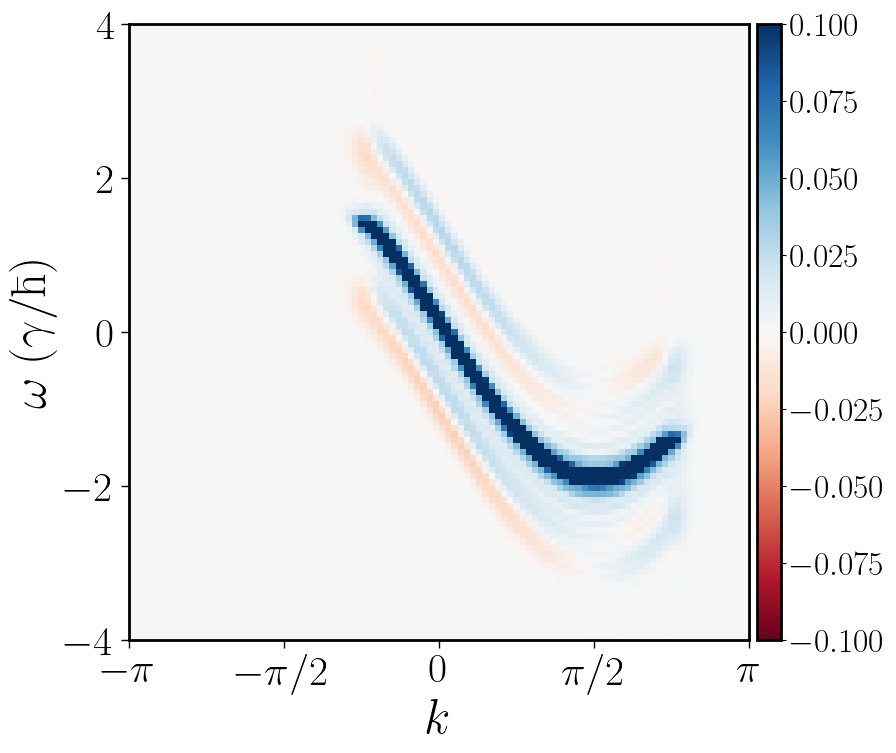

In [484]:
# plt.imshow(-imag.(A_11))

fig,axs=plt.subplots(1,1,figsize=(8,8))

# t_avg1 = 210
# t_avg2 = 499
# t_avg3 = 504
# t_avg4 = 602

fs = 30
t_avg = 110
#t_avg_sol = tavg[t_avg]
#_11println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

#datt = real.(transpose(A_32[:,end:-1:1,t_avg])) #.+ imag.(transpose(GL_32[:,end:-1:1,t_avg]))*pi
datt = imag.(transpose(GL_test_gi[:,end:-1:1,t_avg]))

t1x = -pi
t2x = pi
t1y = ωs_test_gi[1]
t2y = ωs_test_gi[end]

img = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-0.1, vmax=0.1)
plt.ylim(-4,4)

axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
#plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)
box = axs.get_position()
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(img, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)


In [56]:
#sum(As_12[:,80])#/100
@tullio GL_32_sumk[i_ωs,i_tavg] := GL_32[k,i_ωs,i_tavg];
@tullio A_32_sumk[i_ωs,i_tavg] := A_32[k,i_ωs,i_tavg];
@tullio GL_31_sumk[i_ωs,i_tavg] := GL_31[k,i_ωs,i_tavg];
@tullio A_31_sumk[i_ωs,i_tavg] := A_31[k,i_ωs,i_tavg];

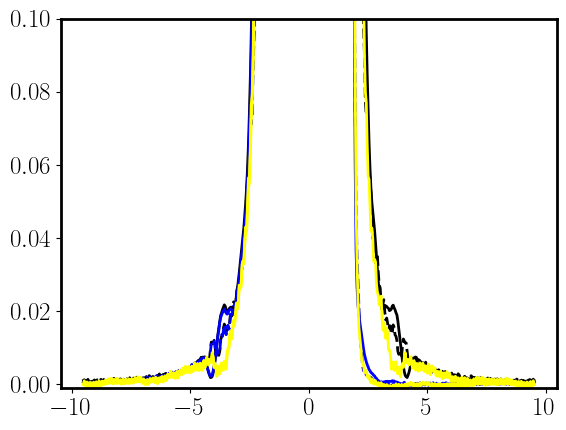

(-0.001, 0.1)

In [57]:
plot(ωs_32, real.(A_32_sumk[:,140]), color="black", linewidth=2,ls="--")
plot(ωs_32, imag.(GL_32_sumk[:,140]), color="blue", linewidth=2,ls="--")

plot(ωs_32, real.(A_32_sumk[:,204]), color="black", linewidth=2)
plot(ωs_32, imag.(GL_32_sumk[:,204]), color="blue", linewidth=2)


plot(ωs_32, real.(A_32_sumk[:,336]), color="yellow", linewidth=2)
plot(ωs_32, imag.(GL_32_sumk[:,336]), color="yellow", linewidth=2)
plt.ylim(-0.001,0.1)

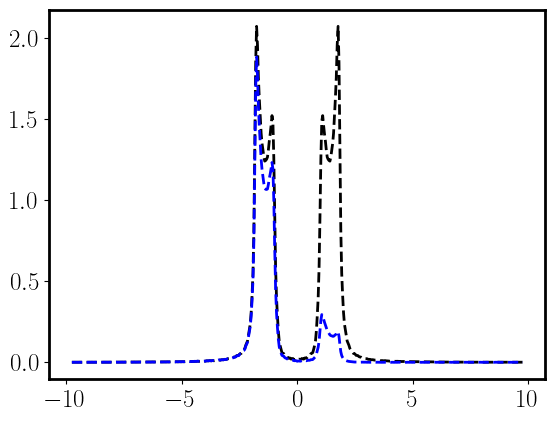

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f75973556a0>

In [278]:
plot(ωs_31, real.(A_31_sumk[:,150]), color="black", linewidth=2,ls="--")
plot(ωs_31, imag.(GL_31_sumk[:,150]), color="blue", linewidth=2,ls="--")


# plot(ωs_31, real.(A_31_sumk[:,190]), color="black", linewidth=2)
# plot(ωs_31, imag.(GL_31_sumk[:,190]), color="blue", linewidth=2)


# plot(ωs_31, real.(A_31_sumk[:,360]), color="yellow", linewidth=2)
#plot(ωs_31, imag.(GL_31_sumk[:,360]), color="yellow", linewidth=2)

#plt.ylim(-0.001,0.1)

### Final figure

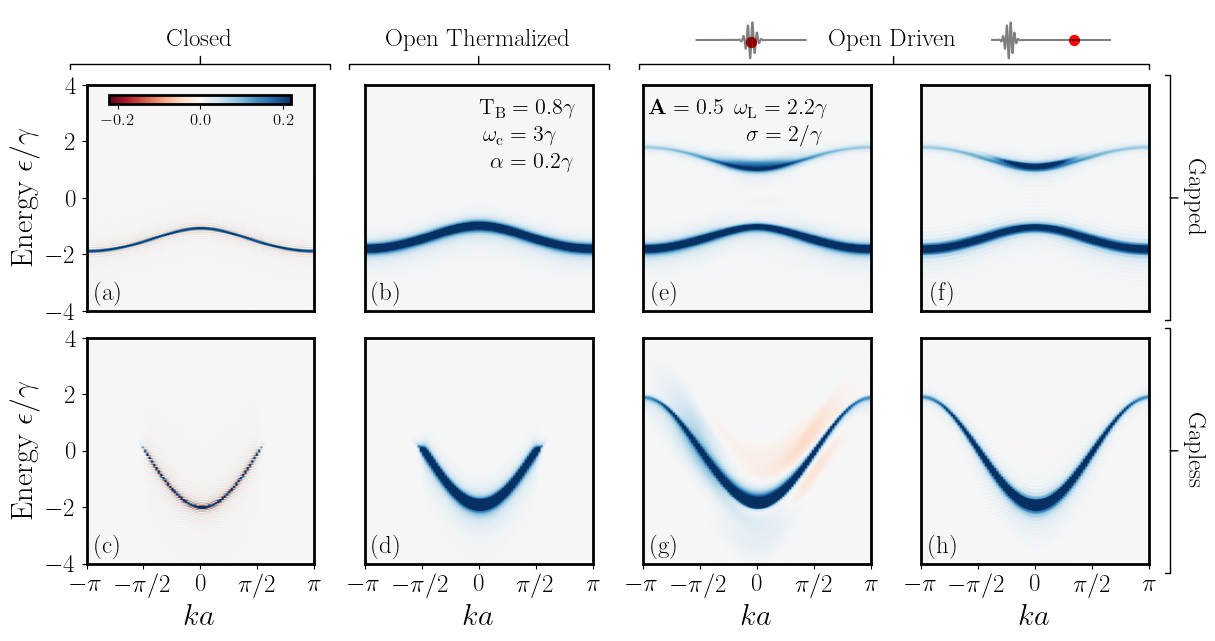

In [329]:
fig, axs = subplots(2, 4, figsize=(12, 6))

cmap = plt.get_cmap("RdBu", 3024)

# t1x = -pi
# t2x = pi
# t1y = ωs[1]
# t2y = ωs[end]

# t_avg1 = 80#200
# t_avg2 = 100#200
# t_avg3 = 110#20
# t_avg4 = 135#30


# datt1 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg1]))
# datt2 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg2]))
# datt3 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg3]))
# datt4 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg4]))

# datt5 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg1]))
# datt6 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg2]))
# datt7 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg3]))
# datt8 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg4]))

# img1 = axs[1,1].imshow(datt1, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
# img2 = axs[1,2].imshow(datt2, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
# img3 = axs[1,3].imshow(datt3, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
# img4 = axs[1,4].imshow(datt4, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)

# img5 = axs[2,1].imshow(datt5, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
# img6 = axs[2,2].imshow(datt6, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
# img7 = axs[2,3].imshow(datt7, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
# img8 = axs[2,4].imshow(datt8, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)

# axs[1,1].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg1], digits=1))\$")
# axs[1,2].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg2], digits=1))\$")
# axs[1,4].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg4], digits=1))\$")

axs[1,1].set_xticks([])
axs[1,2].set_xticks([])
axs[1,3].set_xticks([])
axs[1,4].set_xticks([])
#axs[3,1].set_xticks([])

axs[2,1].set_xticks([])
axs[2,2].set_xticks([])
axs[2,3].set_xticks([])
axs[2,4].set_xticks([])
axs[1,2].set_yticks([])
axs[1,4].set_yticks([])
axs[2,2].set_yticks([])
axs[2,4].set_yticks([])
axs[2,3].set_yticks([])
axs[1,3].set_yticks([])


# axs[3,1].plot()#ωs, real.(A_Wigner_sumk[:,t_avg1]), color="black", linewidth=2)
# axs[3,1].plot()#ωs, imag.(GL_Wigner_sumk[:,t_avg1])/pi, color="blue", linewidth=1.5)


# axs[3,2].plot()#ωs, real.(A_Wigner_sumk[:,t_avg2]), color="black", linewidth=2)
# axs[3,2].plot()#ωs, imag.(GL_Wigner_sumk[:,t_avg2])/pi, color="blue", linewidth=1.5)

# axs[3,3].plot()#ωs, real.(A_Wigner_sumk[:,t_avg3]), color="black", linewidth=2)
# axs[3,3].plot()#ωs, imag.(GL_Wigner_sumk[:,t_avg3])/pi, color="blue", linewidth=1.5)


# axs[3,4].plot()#ωs, real.(A_Wigner_sumk[:,t_avg4]), color="black", linewidth=2)
# axs[3,4].plot()#ωs, imag.(GL_Wigner_sumk[:,t_avg4])/pi, color="blue", linewidth=1.5)

# axs[3,1].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# axs[3,2].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# axs[3,3].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# axs[3,4].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# axs[3,1].set_xlabel(raw"$k$")
# axs[3,2].set_xlabel(raw"$k$")
# axs[3,3].set_xlabel(raw"$k$")
# axs[3,4].set_xlabel(raw"$k$")





axs[2,1].set_xlabel(raw"$ka$")
axs[2,1].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])

axs[2,2].set_xlabel(raw"$ka$")
axs[2,2].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])

axs[2,3].set_xlabel(raw"$ka$")
axs[2,3].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])

axs[2,4].set_xlabel(raw"$ka$")
axs[2,4].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])


axs[1,1].set_ylabel(L"$\mathrm{Energy \ \epsilon/\gamma  }$")
axs[2,1].set_ylabel(L"$\mathrm{Energy \ \epsilon/\gamma  }$")
#axs[3,1].set_ylabel(raw"$A\mathrm{ (\omega, t) }$")
for ax in vec(axs)
    ax.set_ylim(-7,7)  
end

tight_layout()


axs[1,1].annotate(L"$\mathrm{Closed} $", xy=(0.5, 1.08), xytext=(0.5, 1.2), xycoords="axes fraction", 
            ha="center", va="center", rotation=0.0,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=5.2, lengthB=0.2", "lw"=>1.0))



axs[1,2].annotate(L"$\mathrm{Open\ Thermalized} $", xy=(0.5, 1.08), xytext=(0.5, 1.2), xycoords="axes fraction", 
            ha="center", va="center", rotation=0.0,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=5.2, lengthB=0.2", "lw"=>1.0))




axs[1,3].annotate(L"$\mathrm{Open\ Driven } $", xy=(1.1, 1.08), xytext=(1.1, 1.2), xycoords="axes fraction", 
            ha="center", va="center", rotation=0.0,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=10.2, lengthB=0.2", "lw"=>1.0))



axs[1,4].annotate(L"$\mathrm{Gapped} $", xy=(1.08, 0.5), xytext=(1.2, 0.5), xycoords="axes fraction", 
            ha="center", va="center", rotation=270,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=4.9, lengthB=0.2", "lw"=>1.0))


axs[2,4].annotate(L"$\mathrm{Gapless} $", xy=(1.08, 0.5), xytext=(1.2, 0.5), xycoords="axes fraction", 
            ha="center", va="center", rotation=270,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=4.9, lengthB=0.2", "lw"=>1.0))

#------------------------------------------------------------------------------#
ts = 0.0:0.1:50
left, bottom, width, height = [0.59, 0.98, 0.1, 0.1]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.tick_params(left=false, bottom=false, labelleft=false, labelbottom=false)
ax2.plot(ts,pulse.(ts),color="black",alpha =0.5)
ax2.scatter(25.1,pulse(25.1),color="red",s=50)
# 2) Quitar borde (spines)
for sp in ax2.spines.values()
    sp.set_visible(false)
end
#(opcional) quitar también el fondo del recuadro del inset
ax2.set_facecolor("none")      # transparente
ax2.patch.set_alpha(0)         # o equivalente
ax2.set_ylim(-0.8,0.8)
#------------------------------------------------------------------------------#
ts = 0.0:0.1:80
left, bottom, width, height = [0.84, 0.98, 0.1, 0.1]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.tick_params(left=false, bottom=false, labelleft=false, labelbottom=false)
ax3.plot(ts,pulse.(ts),color="black",alpha =0.5)
plt.scatter(60.0,pulse(60.),color="red",s=50)
# 2) Quitar borde (spines)
for sp in ax3.spines.values()
    sp.set_visible(false)
end
#(opcional) quitar también el fondo del recuadro del inset
ax3.set_facecolor("none")      # transparente
ax3.patch.set_alpha(0)         # o equivalente
ax3.set_ylim(-0.8,0.8)
ax3.set_xlim(15,80)

#------------------------------------------------------------------------------#
    
#axs[3,1].set_xlim(-3.5,3.5)
#axs[3,1].set_ylim(-0.1,1.5)

# axs[3,2].set_xlim(-3.5,3.5)
# axs[3,2].set_ylim(-0.1,1.5)

# axs[3,3].set_xlim(-3.5,3.5)
# axs[3,3].set_ylim(-0.1,1.5)

# axs[3,4].set_xlim(-3.5,3.5)
# axs[3,4].set_ylim(-0.1,1.5)


vmin = 0.02
vmax = 0.02
#------------------------------------------------------------------------------# 11
t_avg = 100
#t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
cmap = plt.get_cmap("RdBu", 3024)
# datt11 = datt
datt = imag.(transpose(GL_11[:,end:-1:1,t_avg]))
#imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/38.21)
t1x = -pi
t2x = pi
t1y = ωs_11[1]
t2y = ωs_11[end]
img = axs[1,1].imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-(vmin+0.2), vmax=vmax+0.2)
box = axs[1,1].get_position()
# Parámetros de tamaño/offset (en coords normalizadas de figura)
h  = 0.015          # altura pequeña del colorbar
pad = 0.01          # separación vertical respecto al subplot
# Barra horizontal centrada bajo el eje axs[1,1]
x0 = box.x0 + 0.10*box.width
w  = 0.80*box.width
y0 = box.y0 - pad - h +0.37
cbar_ax = fig.add_axes([x0, y0, w, h])
cbar = fig.colorbar(img, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=16-4)
axs[1,1].set_ylim(-4,4)

#------------------------------------------------------------------------------# 12
t_avg = 300
#t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
cmap = plt.get_cmap("RdBu", 3024)
# datt11 = datt
datt = imag.(transpose(GL_21[:,end:-1:1,t_avg]))
#imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/38.21)
t1x = -pi
t2x = pi
t1y = ωs_21[1]
t2y = ωs_21[end]
img = axs[1,2].imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-vmin, vmax=vmax)
box = axs[1,2].get_position()
# Parámetros de tamaño/offset (en coords normalizadas de figura)
h  = 0.015          # altura pequeña del colorbar
pad = 0.01          # separación vertical respecto al subplot
# Barra horizontal centrada bajo el eje axs[1,1]
x0 = box.x0 + 0.10*box.width
w  = 0.80*box.width
y0 = box.y0 - pad - h +0.37
#cbar_ax = fig.add_axes([x0, y0, w, h])
# cbar = fig.colorbar(img, cax=cbar_ax, orientation="horizontal")
# cbar.ax.tick_params(labelsize=16-4)
# cbar_ax = fig.add_axes([x0, y0, w, h])
# cbar = fig.colorbar(img, cax=cbar_ax, orientation="horizontal")
# cbar.ax.tick_params(labelsize=16-4)
axs[1,2].set_ylim(-4,4)

#------------------------------------------------------------------------------# 12
t_avg = 215
#t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
cmap = plt.get_cmap("RdBu", 3024)
# datt11 = datt
datt = imag.(transpose(GL_31[:,end:-1:1,t_avg]))
#imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/38.21)
t1x = -pi
t2x = pi
t1y = ωs_31[1]
t2y = ωs_31[end]
img = axs[1,3].imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-vmin, vmax=vmax)
box = axs[1,3].get_position()
# Parámetros de tamaño/offset (en coords normalizadas de figura)
h  = 0.015          # altura pequeña del colorbar
pad = 0.01          # separación vertical respecto al subplot
# Barra horizontal centrada bajo el eje axs[1,1]
x0 = box.x0 + 0.10*box.width
w  = 0.80*box.width
y0 = box.y0 - pad - h +0.37
#cbar_ax = fig.add_axes([x0, y0, w, h])
# cbar = fig.colorbar(img, cax=cbar_ax, orientation="horizontal")
# cbar.ax.tick_params(labelsize=16-4)
axs[1,3].set_ylim(-4,4)


#------------------------------------------------------------------------------# 12
t_avg = 360
#t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
cmap = plt.get_cmap("RdBu", 3024)
# datt11 = datt
datt = imag.(transpose(GL_31[:,end:-1:1,t_avg]))
#imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/38.21)
t1x = -pi
t2x = pi
t1y = ωs_31[1]
t2y = ωs_31[end]
img = axs[1,4].imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-vmin, vmax=vmax)
box = axs[1,4].get_position()
# Parámetros de tamaño/offset (en coords normalizadas de figura)
h  = 0.015          # altura pequeña del colorbar
pad = 0.01          # separación vertical respecto al subplot
# Barra horizontal centrada bajo el eje axs[1,1]
x0 = box.x0 + 0.10*box.width
w  = 0.80*box.width
y0 = box.y0 - pad - h +0.37
#cbar_ax = fig.add_axes([x0, y0, w, h])
# cbar = fig.colorbar(img, cax=cbar_ax, orientation="horizontal")
# cbar.ax.tick_params(labelsize=16-4)
axs[1,4].set_ylim(-4,4)

#------------------------------------------------------------------------------# 21

t_avg = 100
#t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
cmap = plt.get_cmap("RdBu", 3024)
# datt11 = datt
datt = imag.(transpose(GL_12[:,end:-1:1,t_avg]))
#
t1x = -pi
t2x = pi
t1y = ωs_12[1]
t2y = ωs_12[end]
img = axs[2,1].imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-(vmin+0.2), vmax=vmax+0.2)
box = axs[2,1].get_position()
axs[2,1].set_ylim(-4,4)

#------------------------------------------------------------------------------# 22

t_avg = 210
#t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
cmap = plt.get_cmap("RdBu", 3024)
# datt11 = datt
datt = imag.(transpose(GL_22[:,end:-1:1,t_avg]))
#
t1x = -pi
t2x = pi
t1y = ωs_22[1]
t2y = ωs_22[end]
img = axs[2,2].imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-vmin, vmax=vmax)
box = axs[2,2].get_position()
axs[2,2].set_ylim(-4,4)

#------------------------------------------------------------------------------# 22

t_avg = 180###207 old value
#t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
cmap = plt.get_cmap("RdBu", 3024)
# datt11 = datt
datt = imag.(transpose(GL_32[:,end:-1:1,t_avg]))
#
t1x = -pi
t2x = pi
t1y = ωs_32[1]
t2y = ωs_32[end]
img = axs[2,3].imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-vmin, vmax=vmax)
box = axs[2,3].get_position()
axs[2,3].set_ylim(-4,4)


#------------------------------------------------------------------------------# 22

t_avg = 336
#t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
cmap = plt.get_cmap("RdBu", 3024)
# datt11 = datt
datt = imag.(transpose(GL_32[:,end:-1:1,t_avg]))
#
t1x = -pi
t2x = pi
t1y = ωs_32[1]
t2y = ωs_32[end]
img = axs[2,4].imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-vmin, vmax=vmax)
box = axs[2,4].get_position()
axs[2,4].set_ylim(-4,4)


# cax = inset_axes(
#     axs[1,1],
#     width="3%",        # grosor del colorbar (relativo al ax)
#     height="35%",      # altura (relativo al ax)
#     loc="lower right", # esquina
#     borderpad=0.8      # margen interno respecto al borde
# )

# cb = fig.colorbar(img, cax=cax)
#cax = fig.add_axes([0.78, 0.15, 0.03, 0.25])  # [left, bottom, width, height]
#cb = fig.colorbar(img, cax=cax)
#cb.axs[1,1].tick_params(labelsize=8, length=2)

# axs.set_xlabel(raw"$k$", fontsize=fs+5)
# axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
# axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
# axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
# axs.yaxis.offsetText.set_fontsize(fs)
# xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
#plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)


#------------------------------------------------------------------------------#

#index = [raw"$\rm{(a)}$",raw"$\rm{(b)}$",raw"$\rm{(c)}$",raw"$\rm{(d)}$",raw"$\rm{(e)}$",raw"$\rm{(f)}$",raw"$\rm{(g)}$",raw"$\rm{(h)}$" ]
#['(a)','(b)','(c)','(d)']
index = [raw"$\rm{(a)}$",raw"$\rm{(c)}$",raw"$\rm{(b)}$",raw"$\rm{(d)}$",raw"$\rm{(e)}$",raw"$\rm{(g)}$",raw"$\rm{(f)}$",raw"$\rm{(h)}$" ]#['(a)','(b)','(c)','(d)']

i=1
for axes in axs
    axes.text(x=0.1, y=0.05, s=index[i],ha="center", transform=axes.transAxes)
#axs.text(x=0.95, y=0.93, s=index[i],fontsize=fs,ha='center', transform=ax.transAxes)
    
    #axes.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
    axes.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
    #axes.yaxis.offsetText.set_fontsize(fs)
    i=i+1
end

axs[1,2].text(x=0.5, y=0.87, s=L"$\mathrm{T_B = 0.8\gamma}$", transform=axs[1,2].transAxes,fontsize=16)
axs[1,2].text(x=0.52, y=0.75, s=L"$\mathrm{\omega_c = 3\gamma}$", transform=axs[1,2].transAxes,fontsize=16)
axs[1,2].text(x=0.55, y=0.63, s=L"$\mathrm{\alpha = 0.2\gamma}$", transform=axs[1,2].transAxes,fontsize=16)


axs[1,3].text(x=0.02, y=0.87, s=L"$\mathrm{\mathbf{A}= 0.5}$", transform=axs[1,3].transAxes,fontsize=16)
axs[1,3].text(x=0.4, y=0.87, s=L"$\mathrm{\omega_L = 2.2\gamma}$", transform=axs[1,3].transAxes,fontsize=16)
axs[1,3].text(x=0.45, y=0.75, s=L"$\mathrm{\sigma = 2/\gamma}$", transform=axs[1,3].transAxes,fontsize=16)

axs[1,1].yaxis.set_major_locator(mpl_ticker.MaxNLocator(5))
axs[2,1].yaxis.set_major_locator(mpl_ticker.MaxNLocator(5))

plt.savefig("G_lesser.pdf", bbox_inches="tight")
#fig.subplots_adjust(right=1.14)    # mueve toda la grilla a la izquierda

#fig.colorbar()#img1, ax=vec(axs), location="right", pad=0.10)

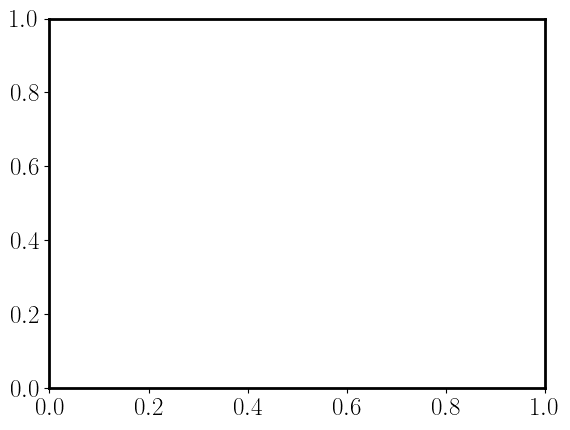

PyObject Bbox([[0.125, 0.10999999999999999], [0.9, 0.88]])

In [295]:
fig,axs = plt.subplots()
cmap = plt.get_cmap("RdBu", 3024)
datt = -imag.(transpose(GL_11[:,end:-1:1,t_avg]))
#imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/38.21)
t1x = -pi
t2x = pi
t1y = ωs_11[1]
t2y = ωs_11[end]
#img = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-0.55, vmax=0.55)
box = axs.get_position()

In [314]:
t0= 25.0
ω0 = 3.0#Float64(6pi)
σ = 2.0
A = 0.5

0.5

In [315]:
function pulse_Gaussian_sin(t::Float64; t0::Float64, ω0::Float64, σ::Float64, A::Float64)
    #(; t0, ω0, σ, A) = model
    A * exp(-0.5 * (t-t0)^2 / σ^2) * sin(t * ω0)
end

pulse_Gaussian_sin (generic function with 1 method)

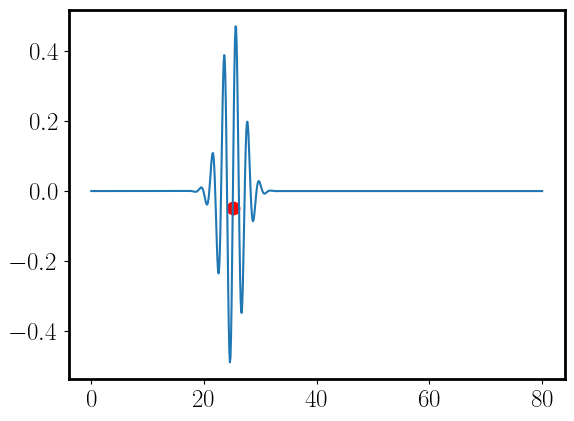

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f16301d5fd0>

In [316]:

pulse(t) = pulse_Gaussian_sin(t;t0,ω0,σ,A)
plt.scatter(25.1,pulse(25.1),color="red",s=80)
plt.ylim()
plt.plot(ts,pulse.(ts))

# pulse(0.1)

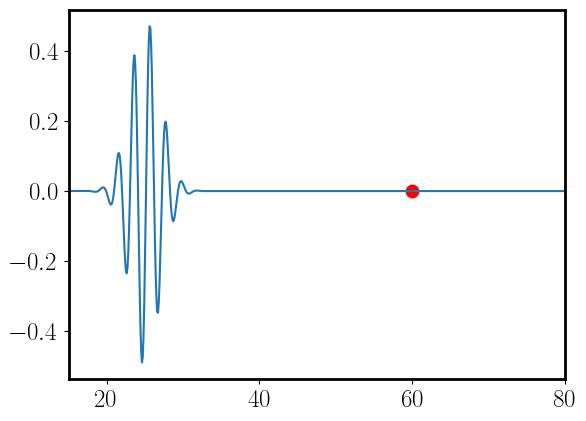

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f16087af890>

In [317]:

pulse(t) = pulse_Gaussian_sin(t;t0,ω0,σ,A)
plt.scatter(60.0,pulse(60.),color="red",s=80)
#plt.ylim()

plt.xlim(15,80)
plt.plot(ts,pulse.(ts))

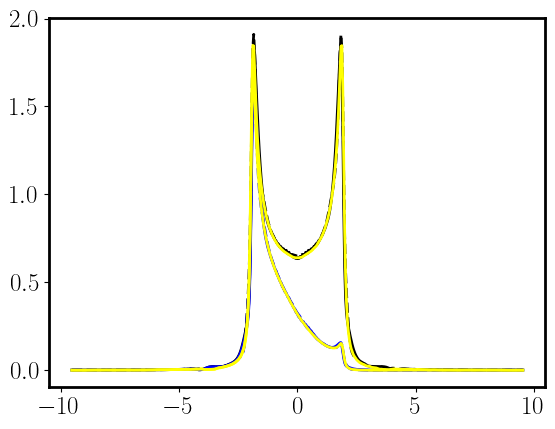

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f759517a900>

In [155]:
plot(ωs_32, real.(A_32_sumk[:,140]), color="black", linewidth=2,ls="--")
plot(ωs_32, imag.(GL_32_sumk[:,140]), color="blue", linewidth=2,ls="--")

plot(ωs_32, real.(A_32_sumk[:,204]), color="black", linewidth=2)
plot(ωs_32, imag.(GL_32_sumk[:,204]), color="blue", linewidth=2)


plot(ωs_32, real.(A_32_sumk[:,336]), color="yellow", linewidth=2)
plot(ωs_32, imag.(GL_32_sumk[:,336]), color="yellow", linewidth=2)

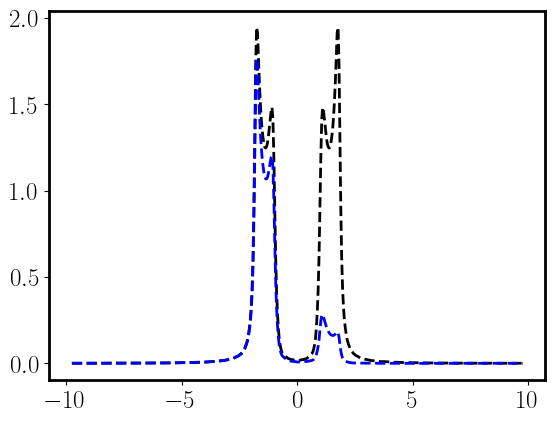

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f75951dafc0>

In [156]:
plot(ωs_31, real.(A_31_sumk[:,150]), color="black", linewidth=2,ls="--")
plot(ωs_31, imag.(GL_31_sumk[:,150]), color="blue", linewidth=2,ls="--")


# plot(ωs_31, real.(A_31_sumk[:,213]), color="black", linewidth=2)
# plot(ωs_31, imag.(GL_31_sumk[:,213]), color="blue", linewidth=2)


# plot(ωs_31, real.(A_31_sumk[:,360]), color="yellow", linewidth=2)
#plot(ωs_31, imag.(GL_31_sumk[:,360]), color="yellow", linewidth=2)

#plt.ylim(-0.001,0.1)

sys:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


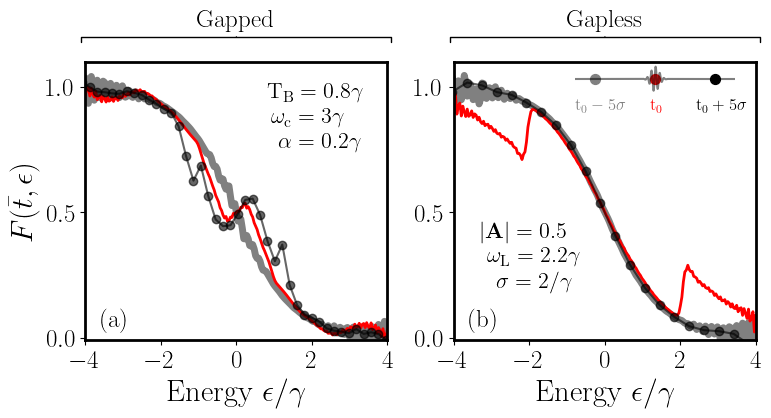

In [330]:
#As_11

#
fig, axs = subplots(1, 2, figsize=(8, 4))

axs[1,1].set_ylabel(L"$F(\bar t, \epsilon  )$")
axs[1,1].set_ylabel(L"$F(\bar t, \epsilon  )$")

axs[1,1].set_xlabel(L"$\mathrm{Energy \ \epsilon/ \gamma  }$")
axs[2,1].set_xlabel(L"$\mathrm{Energy \ \epsilon/ \gamma  }$")
axs[2,1].set_yticks([])

min =-1.0
max = 1.5

GL_im=imag.(GL_31_sumk[:,118])
A_col=real.(A_31_sumk[:,118])
mask2 = min .< GL_im./A_col .< max
ratio1 = fill(NaN, length(A_col))
ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])
axs[1,1].plot(ωs_31,ratio1,color="gray",lw=5.,label=L"$\mathrm{Open\ Thermalized}$")
#axs[1,1].plot(ωs_31,GL_im./A_col,color="black",lw=2.)

GL_im=imag.(GL_31_sumk[:,184])
A_col=real.(A_31_sumk[:,184])
mask2 = min .< GL_im./A_col .< max
ratio1 = fill(NaN, length(A_col))
ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])
axs[1,1].plot(ωs_31,ratio1,color="red",lw=2.,label=L"$\mathrm{Pulse\ Driven}$")
#axs[1,1].plot(ωs_31,GL_im./A_col,color="black",lw=2.)

GL_im=imag.(GL_31_sumk[:,250])
A_col=real.(A_31_sumk[:,250])
mask2 = min .< GL_im./A_col .< max
ratio1 = fill(NaN, length(A_col))
ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])
axs[1,1].plot(ωs_31[1:5:end],ratio1[1:5:end],color="black",marker = "o",alpha=0.6,label=L"$\mathrm{After\ pulse}$")
#axs[1,1].plot(ωs_31,GL_im./A_col,color="blue",lw=2.,ls="--")






### init
GL_im=imag.(GL_32_sumk[:,119])
A_col=real.(A_32_sumk[:,119])
mask2 = min .< GL_im./A_col .< max
ratio1 = fill(NaN, length(A_col))
ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])
axs[2,1].plot(ωs_32,ratio1,color="gray",lw=5.,ls = "-")
#axs[2,1].plot(ωs_32,GL_im./A_col,color="black",lw=2.)
GL_im=imag.(GL_32_sumk[:,180])
A_col=real.(A_32_sumk[:,180])
mask2 = min .< GL_im./A_col .< max
ratio1 = fill(NaN, length(A_col))
ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])
axs[2,1].plot(ωs_32,ratio1,color="red",lw=2.)

#axs[2,1].plot(ωs_32,GL_im./A_col,color="red",lw=2.)
GL_im=imag.(GL_32_sumk[:,245])
A_col=real.(A_32_sumk[:,245])
mask2 = min .< GL_im./A_col .< max
ratio1 = fill(NaN, length(A_col))
ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])
axs[2,1].plot(ωs_32[1:10:end],ratio1[1:10:end],color="black",marker = "o",alpha=0.6)
#axs[1,1].legend(frameon=false,fontsize=10)
axs[2,1].text(x=0.4, y=0.83, s=L"$\mathrm{t_0-5\sigma}$", transform=axs[2,1].transAxes,fontsize=12,color="gray")
axs[2,1].text(x=0.65, y=0.83, s=L"$\mathrm{t_0}$", transform=axs[2,1].transAxes,fontsize=12,color="red")
axs[2,1].text(x=0.8, y=0.83, s=L"$\mathrm{t_0+5\sigma}$", transform=axs[2,1].transAxes,fontsize=12,color="black")
t0= 40.0
ω0 = 3.0#Float64(6pi)
σ = 2.0
A = 0.5
pulse(t) = pulse_Gaussian_sin(t;t0,ω0,σ,A)
ts = 0.0:0.1:80
left, bottom, width, height = [0.74, 0.84, 0.2, 0.1]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.tick_params(left=false, bottom=false, labelleft=false, labelbottom=false)
ax3.plot(ts,pulse.(ts),color="black",alpha =0.5)
#ax3.xli3
plt.scatter(10.0,0.0,color="gray",s=50)

plt.scatter(40.0,0.0,color="red",s=50,alpha=0.9)

plt.scatter(70.0,0.0,color="black",s=50)
# 2) Quitar borde (spines)
for sp in ax3.spines.values()
    sp.set_visible(false)
end
#(opcional) quitar también el fondo del recuadro del inset
ax3.set_facecolor("none")      # transparente
ax3.patch.set_alpha(0)         # o equivalente
ax3.set_ylim(-0.8,0.8)
ax3.set_xlim(0,80)

axs[1,1].text(x=0.6, y=0.87, s=L"$\mathrm{T_B = 0.8\gamma}$", transform=axs[1,1].transAxes,fontsize=16)
axs[1,1].text(x=0.615, y=0.78, s=L"$\mathrm{\omega_c = 3\gamma}$", transform=axs[1,1].transAxes,fontsize=16)
axs[1,1].text(x=0.638, y=0.69, s=L"$\mathrm{\alpha = 0.2\gamma}$", transform=axs[1,1].transAxes,fontsize=16)


axs[2,1].text(x=0.091, y=0.37, s=L"$\mathrm{|\mathbf{A}|= 0.5}$", transform=axs[2,1].transAxes,fontsize=16)
axs[2,1].text(x=0.11, y=0.28, s=L"$\mathrm{\omega_L = 2.2\gamma}$", transform=axs[2,1].transAxes,fontsize=16)
axs[2,1].text(x=0.14, y=0.19, s=L"$\mathrm{\sigma = 2/\gamma}$", transform=axs[2,1].transAxes,fontsize=16)

index = [raw"$\rm{(a)}$",raw"$\rm{(b)}$",raw"$\rm{(b)}$",raw"$\rm{(d)}$",raw"$\rm{(e)}$",raw"$\rm{(g)}$",raw"$\rm{(f)}$",raw"$\rm{(h)}$" ]#['(a)','(b)','(c)','(d)']

i=1
for axes in axs
    axes.text(x=0.1, y=0.05, s=index[i],ha="center", transform=axes.transAxes)
#axs.text(x=0.95, y=0.93, s=index[i],fontsize=fs,ha='center', transform=ax.transAxes)
    
    #axes.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
    axes.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
    #axes.yaxis.offsetText.set_fontsize(fs)
    i=i+1
end

axs[2,1].set_yticks([0.0,0.5,1.0])
axs[1,1].set_yticks([0.0,0.5,1.0])
axs[1,1].set_ylim(-0.01,1.1)
axs[2,1].set_ylim(-0.01,1.1)
axs[1,1].set_xlim(-4,4)
axs[2,1].set_xlim(-4,4)
#axs[2,2].set_xlabel(L"$\mathrm{Energy \ (\gamma)  }$")
tight_layout()

axs[1,1].annotate(L"$\mathrm{Gapped} $", xy=(0.5, 1.08), xytext=(0.5, 1.15), xycoords="axes fraction", 
            ha="center", va="center", rotation=0.0,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=6.2, lengthB=0.2", "lw"=>1.0))
axs[2,1].annotate(L"$\mathrm{Gapless} $", xy=(0.5, 1.08), xytext=(0.5, 1.15), xycoords="axes fraction", 
            ha="center", va="center", rotation=0.0,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=6.2, lengthB=0.2", "lw"=>1.0))

plt.savefig("F_distribution.pdf", bbox_inches="tight")

In [140]:
println(t_32[119])

println(t_32[180])

println(t_32[245])

19.4238683127572
29.46502057613169
40.16460905349794


In [144]:

println(t_31[120])
println(t_31[184])

println(t_31[250])


#println(t_31[210])

19.116465863453815
29.397590361445783
40.0


In [305]:
t_31

499-element Vector{Float64}:
  0.0
  1.0e-6
  5.999999999999999e-6
  3.0999999999999995e-5
  0.00015599999999999997
  0.0007809999999999998
  0.0013434999999999996
  0.0018497499999999994
  0.004380999999999998
  0.01703724999999999
  0.028427874999999984
  0.08538099999999996
  0.13663881249999993
  ⋮
 78.13527030943514
 78.31760337758149
 78.49993755169652
 78.68258641462069
 78.86555986415443
 79.04861882263955
 79.23151812237579
 79.41417837823116
 79.59686093560741
 79.77994575857568
 79.96345479680524
 80.0

In [175]:
length(ωs_32)

487

In [303]:
println(t_32[180])

println(t_32[206])

25.715790162797752
29.882943319046994


19.09275216199495
20.72997283755678
22.380028562377948
24.042238715538335
25.715790162797752
27.3936609666244
28.996382642981548
30.46181769346776
31.92430794211803
33.43527889668664
35.12179206314207
36.86184447481557
38.61213753368365
40.37059017518628
42.136897497505565
43.91082481147462
45.69215356163818
47.4806786485715
49.27620715423022
51.07855724407924


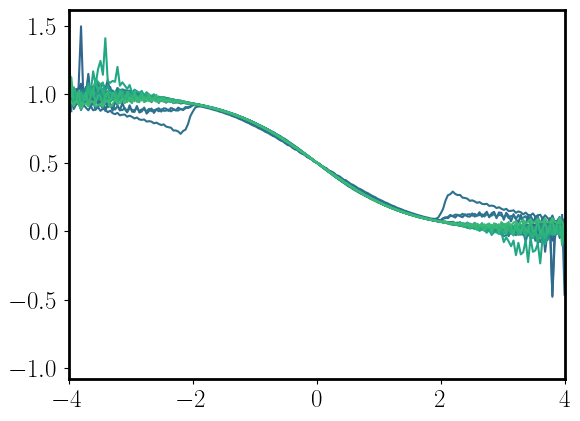

(-4.0, 4.0)

In [286]:
cmap = plt.cm.viridis


# GL_im=imag.(GL_32_sumk[:,203])
# A_col=real.(A_32_sumk[:,203])
# mask2 = min .< GL_im./A_col .< max
# ratio1 = fill(NaN, length(A_col))
# ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])
# plt.plot(ωs_32,ratio1,color="red",lw=2.)


for i in 140:10:336
    println(t_32[i])
    GL_im=imag.(GL_32_sumk[:,i])
    A_col=real.(A_32_sumk[:,i])
    mask2 = min .< GL_im./A_col .< max
    Y = fill(NaN, length(A_col))
    Y[mask2] .= GL_im[mask2] ./ (A_col[mask2])
    
    plt.plot(ωs_32, Y, color=cmap(i/(length(ωs_32)-1)))
    
end
plt.xlim(-4,4)


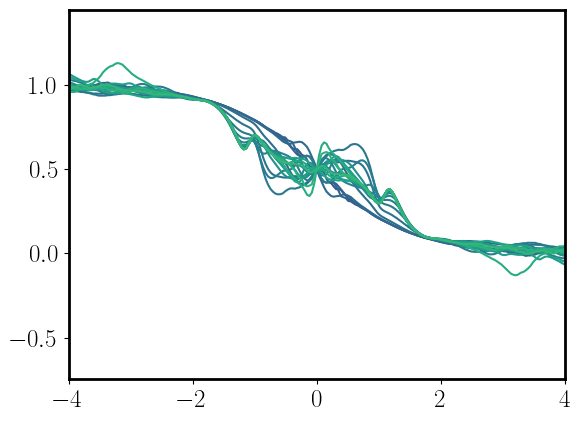

(-4.0, 4.0)

In [180]:
cmap = plt.cm.viridis


# GL_im=imag.(GL_32_sumk[:,203])
# A_col=real.(A_32_sumk[:,203])
# mask2 = min .< GL_im./A_col .< max
# ratio1 = fill(NaN, length(A_col))
# ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])
# plt.plot(ωs_32,ratio1,color="red",lw=2.)


for i in 140:10:336

    GL_im=imag.(GL_31_sumk[:,i])
    A_col=real.(A_31_sumk[:,i])
    mask2 = min .< GL_im./A_col .< max
    Y = fill(NaN, length(A_col))
    Y[mask2] .= GL_im[mask2] ./ (A_col[mask2])
    
    plt.plot(ωs_31, Y, color=cmap(i/(length(ωs_31)-1)))
    
end
plt.xlim(-4,4)

In [79]:
fig, axs = subplots(2, 2, figsize=(8, 8))

axs[1,1].set_ylabel(L"$F(\bar t, \epsilon  )$")


axs[2,1].set_xlabel(L"$\mathrm{Energy \ (\gamma)  }$")
axs[2,2].set_xlabel(L"$\mathrm{Energy \ (\gamma)  }$")
axs[1,1].set_xlim(-3,3)
axs[1,2].set_xlim(-3,3)
axs[2,1].set_xlim(-3,3)
axs[2,2].set_xlim(-3,3)


axs[1,1].set_xticks([])
axs[1,2].set_xticks([])

axs[1,2].set_yticks([])
axs[2,2].set_yticks([])



axs[2,1].set_ylabel(L"$\mathrm{Im}\ G^{<}(\bar t, \epsilon  )$")

t_avg = 70#300
#t_avg_sol = tavg[t_avg]




axs[2,1].plot(ωs_11, As_11, color="gray", linewidth=7,alpha=0.4)

# axs[2,1].plot(ωs_11, GL_11, color="blue", linewidth=1.5,ls="--")
# axs[2,1].set_xlim(-5,5)
# xlabel(raw"$\omega(\gamma/\hbar)$")
# ylabel(raw"$A(\omega,t_{\text{avg}})$")
#println(t_avg_sol)

# ϵs = -3:0.1:3
# axs[1,1].plot(ϵs,fermi.(ϵs;T=0.1),color = "gray")
#function fermi(ϵ; T)



# δ = 1e-3

# A_col   = real.(A_Wigner_sumk[:, t_avg])
# GL_im   = imag.(GL_Wigner_sumk[:, t_avg])/pi
# # Máscara de puntos "seguros"
# #mask = abs.(A_col) .> δ

# mask2 = 0.01 .< GL_im./A_col .< 1.0

# ratio1 = fill(NaN, length(A_col))

# ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])

# axs[1,1].scatter(ωs,ratio1,color="blue",ls = "-")
# axs[1,1].set_xlim(-2.4,2.4)

# axs[2,1].set_xlim(-2.4,2.4)
# axs[1,1].set_ylim(0.0,1.1)

tight_layout()


LoadError: UndefVarError: `As_11` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [166]:
#### Stored data for  figures
#t_avg = 80#300
#datt_11 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/38.21) <- closed-rice mele
# A_11 = real.(A_Wigner_sumk[:,t_avg])/38.21
# GL_11 =  imag.(GL_Wigner_sumk[:,t_avg])/pi/(38.21)

# t_avg = 80
# datt_12 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/25.15) #<- closed-chain
# A_12 = real.(A_Wigner_sumk[:,t_avg])/25.15
# GL_12 =  imag.(GL_Wigner_sumk[:,t_avg])/pi/(25.15)



#ratio1

146-element Vector{Float64}:
   0.500000000773805
   0.6027398623876118
   0.733195387654891
   0.7245820194645411
   0.9253692248909995
 NaN
   0.6830317379036478
   0.15343894373108985
 NaN
 NaN
   0.9289896695043988
   0.7465497478063352
   0.7530376392234
   ⋮
   0.24696236088335619
   0.25345025226710477
   0.0710103306500766
 NaN
 NaN
   0.8465610549593083
   0.3169682600877567
 NaN
   0.07463077496075596
   0.2754179801803558
   0.26680461314360177
   0.39726013880495653

### Raw functions and figures


In [235]:
Nt = length(ts)
T = maximum(ts)
Δ = ts .- ts'

# Windowing function W(t)
W = @.exp(-4.0 * (Δ^2) / T^2)



# GL_filt_11 = similar(GL_data)[1,1,:,:,:]
# GG_filt_11 = similar(GG_data)[1,1,:,:,:]
# for k in 1:size(GL_data,3)
#     @views GL_filt_11[k, :, :] = (GL_data[1,1,k, :, :] .+ GL_data[2,2,k, :, :]    ).* W #+ GL_data[2,2,k, :, :] 
#     @views GG_filt_11[k, :, :] = (GG_data[1,1,k, :, :] .+ GG_data[2,2,k, :, :]    ) .* W
# end

GL_filt = similar(GL_data)
GG_filt = similar(GG_data)

for k in 1:size(GL_data,1)
    @views GL_filt[k, :, :] = GL_data[k, :, :] .* W
    @views GG_filt[k, :, :] = GG_data[k, :, :] .* W
end

function wigner_transform_itp(x, ts::Vector; fourier = true, ts_lin = range(first(ts), last(ts); length = length(ts)))
    itp = interpolate((ts, ts), x, Gridded(Linear()))
    return wigner_transform([itp(t1, t2) for t1 in ts_lin, t2 in ts_lin]; ts = ts_lin, fourier = fourier)
end

wigner_transform_itp (generic function with 1 method)

In [197]:
GL_Wigner_list = []
F_Wigner_list = []
A_Wigner_list = []

tavg_list = []
ωs_list = []

for k in 1:L
    # GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt_11[k, :, :], ts; fourier=true)
    # GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt_11 - GL_filt_11)[k, :, :], ts; fourier=true)
    # GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt[k, :, :], ts; fourier=true)
    # GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt - GL_filt)[k, :, :], ts; fourier=true)
    F_Wigner = - 0.5 * imag(GL_Wigner_FFT) ./ (imag(GR_Wigner_FFT))
    A_Wigner = - imag(GR_Wigner_FFT)/pi

    push!(GL_Wigner_list, GL_Wigner_FFT)
    push!(F_Wigner_list, F_Wigner)
    push!(A_Wigner_list, A_Wigner)
    
    push!(tavg_list, tavg)
    push!(ωs_list, ωs)
end

In [198]:
#dim_tavg = size(GL_data)[4]
dim_tavg = size(GL_data)[2]
GL_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
F_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
A_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)

for i in 1:L
    for k in 1:dim_tavg
        for j in 1:dim_tavg
            GL_Wigner_tensor[i,j,k] = GL_Wigner_list[i][j,k]
            F_Wigner_tensor[i,j,k] = F_Wigner_list[i][j,k]
            A_Wigner_tensor[i,j,k] = A_Wigner_list[i][j,k]
        end
    end
end

In [199]:
# GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt_11[Int(L/2), :, :], ts; fourier=true)
# GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt_11 .- GL_filt_11)[Int(L/2), :, :], ts; fourier=true)

GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt[Int(L/2), :, :], ts; fourier=true)
GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt .- GL_filt)[Int(L/2), :, :], ts; fourier=true)

(ComplexF64[1.3361683093566119e-12 - 0.47904191616765956im -2.9384849326351435e-13 + 0.10535507665597574im … -2.0253991180653307e-13 + 0.07261503131417048im 1.3361683093566119e-12 - 0.47904191616765956im; 1.3141167957883576e-12 - 0.4790419161676595im -2.1025306455428832e-13 + 0.07663552670706432im … -1.1842339225421555e-13 + 0.043186475096693294im 1.3141167957883576e-12 - 0.4790419161676595im; … ; -1.2920724659126043e-12 - 0.47904191616765945im 4.3293314852196325e-13 + 0.16049561863784728im … 3.483457824383527e-13 + 0.12913493245754532im -1.2920724659126043e-12 - 0.47904191616765945im; -1.3141699801248668e-12 - 0.47904191616765956im 3.6578261610350654e-13 + 0.13332147848015763im … 2.7783128617550393e-13 + 0.1012778796295063im -1.3141699801248668e-12 - 0.47904191616765956im], (-6.558074664368763:0.07807231743296146:6.480002346935801, 0.0:0.23952095808383234:40.0))

In [200]:
@tullio GL_Wigner_sumk[i_ωs,i_tavg] := GL_Wigner_tensor[k,i_ωs,i_tavg];
@tullio A_Wigner_sumk[i_ωs,i_tavg] := A_Wigner_tensor[k,i_ωs,i_tavg];

GL_Wigner_sumk = GL_Wigner_sumk./L
A_Wigner_sumk = A_Wigner_sumk./L
F_Wigner_sumk = (1/(2pi)) * imag.(GL_Wigner_sumk) ./ A_Wigner_sumk;

In [201]:
# import matplotlib
# matplotlib.use("TkAgg")   # o "QtAgg

18.922155688622755


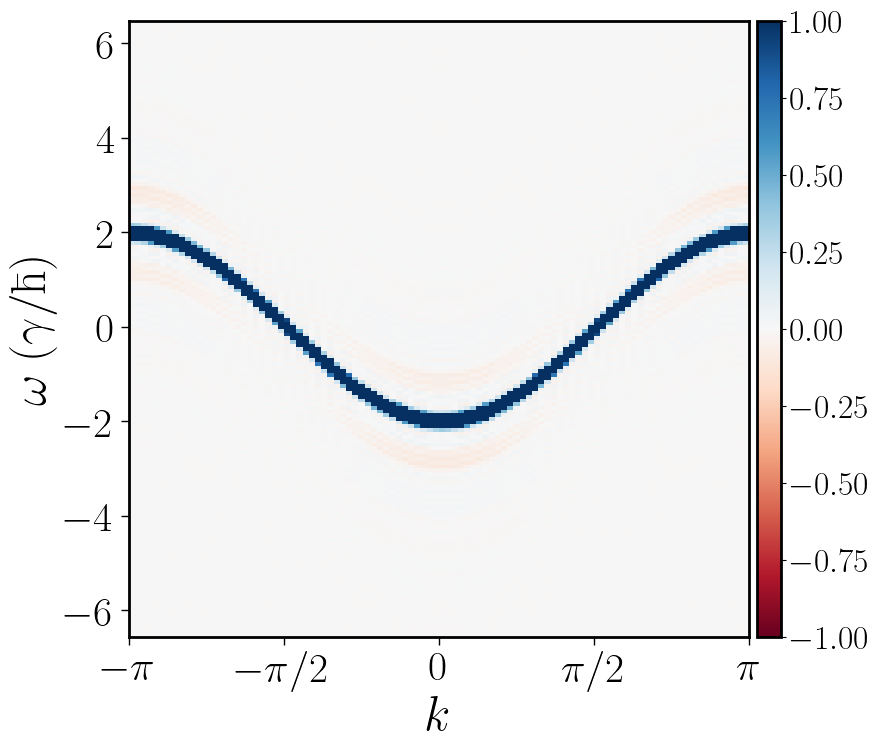

In [202]:
fig,axs=plt.subplots(1,1,figsize=(8,8))

# t_avg1 = 210
# t_avg2 = 499
# t_avg3 = 504
# t_avg4 = 602

fs = 30
t_avg = 80
t_avg_sol = tavg[t_avg]
println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

datt = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg]))

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

img = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1, vmax=1)

axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
#plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)
box = axs.get_position() 
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(img, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)
#cbar.set_label(raw"$A\mathrm{(\omega,t_{\text{avg}})}$", fontsize=fs-2,rotation=270,labelpad=35)
# plt.show()

18.922155688622755


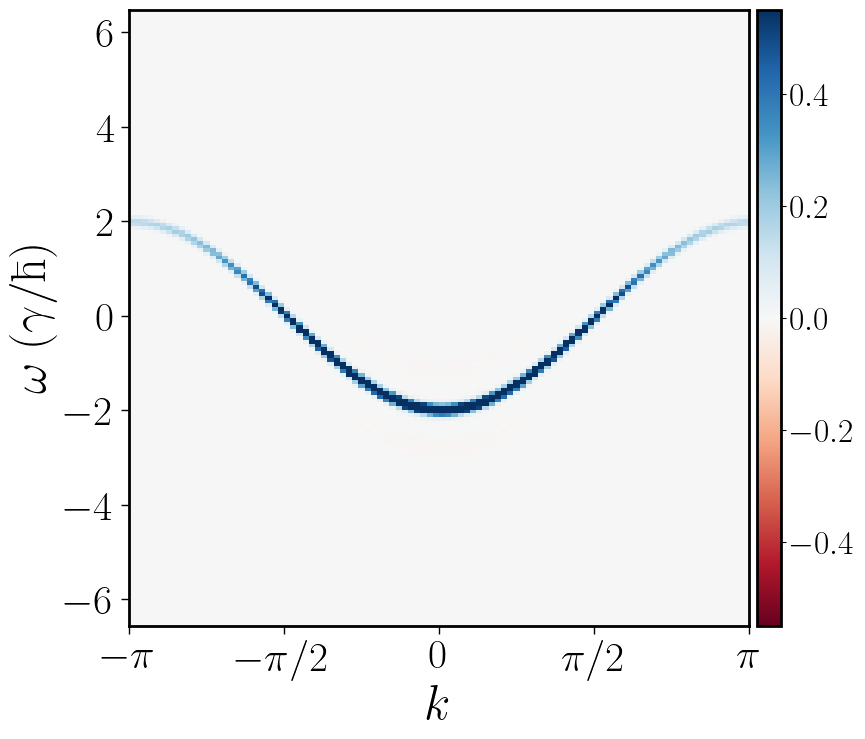

In [206]:
fig,axs=plt.subplots(1,1,figsize=(8,8))

fs = 30
t_avg = 80
t_avg_sol = tavg[t_avg]

println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

datt = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/25.15)

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

img = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-0.55, vmax=0.55)

axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
#plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)

box = axs.get_position() 
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(img, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)
#cbar.set_label(raw"$\text{Im}G^{<}\mathrm{(\omega,t_{\text{avg}})}$", fontsize=fs-2,rotation=270,labelpad=35)

In [207]:
# t1 = 1
# t2 = length(ts)
# sol_t1 = ts[t1]
# sol_t2 = ts[t2]
# nf_t1  = imag.(GL_data[t1,t1])
# nf_t2 = imag.(GL_data[t2,t2])

# plot(ks, nf_t1; color="red", linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
# plot(ks, nf_t2; color="blue", linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="-.")
# xlabel(raw"$k$")
# ylabel(raw"$n_{\text{F}}$")
# xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# legend(frameon=false)
# tight_layout()

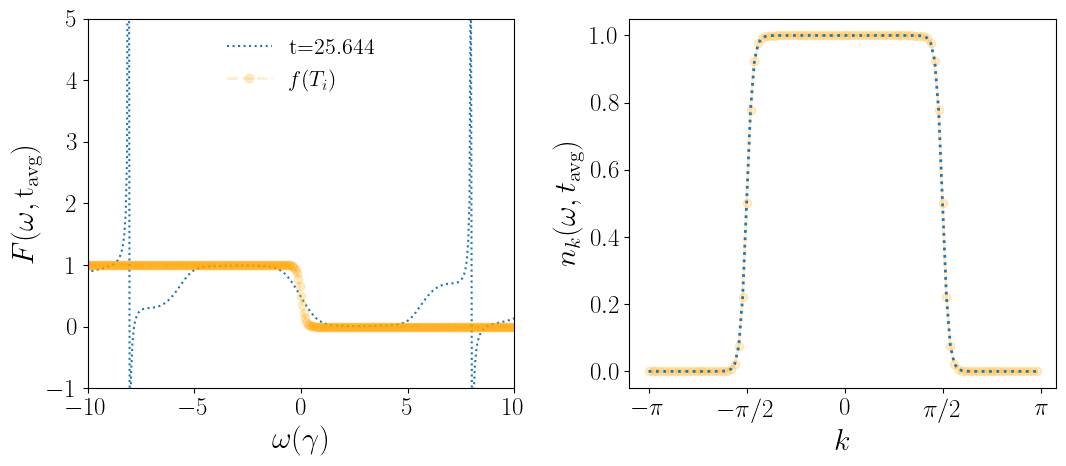

In [61]:
fig, axs = subplots(1, 2, figsize=(11, 5))


t_avg1 = 10
t_avg_sol1 = tavg[t_avg1]

t_avg2 = 30
t_avg_sol2 = tavg[t_avg2]

t_avg3 = 180
t_avg_sol3 = tavg[t_avg3]


t_avg4 = 220
t_avg_sol4 = tavg[t_avg4]

#println(t_avg_sol)
δ = 1e-6
A_col1   = real.(A_Wigner_sumk[:, t_avg1])
GL_im1   = imag.(GL_Wigner_sumk[:, t_avg1])/pi
# Máscara de puntos "seguros"
mask1 = abs.(A_col1) .> δ
ratio1 = fill(NaN, length(A_col1))
ratio1[mask1] .= GL_im1[mask1] ./ A_col1[mask1]


A_col2   = real.(A_Wigner_sumk[:, t_avg2])
GL_im2   = imag.(GL_Wigner_sumk[:, t_avg2])/pi
# Máscara de puntos "seguros"
mask2 = abs.(A_col2) .> δ
ratio2 = fill(NaN, length(A_col2))
ratio2[mask2] .= GL_im2[mask2] ./ A_col2[mask2]


A_col3   = real.(A_Wigner_sumk[:, t_avg3])
GL_im3   = imag.(GL_Wigner_sumk[:, t_avg3])/pi
# Máscara de puntos "seguros"
mask3 = abs.(A_col3) .> δ
ratio3 = fill(NaN, length(A_col3))
ratio3[mask3] .= GL_im3[mask3] ./ A_col3[mask3]



A_col4   = real.(A_Wigner_sumk[:, t_avg4])
GL_im4   = imag.(GL_Wigner_sumk[:, t_avg4])/pi
# Máscara de puntos "seguros"
mask4 = abs.(A_col4) .> δ
ratio4 = fill(NaN, length(A_col4))
ratio4[mask4] .= GL_im4[mask4] ./ A_col4[mask4]


nf_t1  = imag.(GL_data[t_avg1,t_avg1])
nf_t2 = imag.(GL_data[t_avg2,t_avg2])
nf_t3 = imag.(GL_data[t_avg3,t_avg3])
nf_t4 = imag.(GL_data[t_avg4,t_avg4])


axs[2,1].plot(ks, nf_t1; lw=2,marker = "o",alpha=0.2 ,label = raw"$f(T_i)$",color="orange")
#axs[2,1].plot(ks, nf_t1; linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
#axs[2,1].plot(ks, nf_t2; linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="--")
#axs[2,1].plot(ks, nf_t2; linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="-.")
axs[2,1].plot(ks, nf_t2; linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle=":")
axs[2,1].set_xlabel(raw"$k$")
axs[2,1].set_ylabel(raw"$n_k{(\omega,t_{\text{avg}})}$")

axs[1,1].set_xlabel(raw"$\omega(\gamma)$")
axs[1,1].set_ylabel(raw"$F\mathrm{(\omega,t_{\text{avg}})}$")
#axs[1,1].plot(ωs,ratio1,label = "t=$(round(t_avg_sol1,digits=1))")
#axs[1,1].plot(ωs,ratio2,label = "t=$(round(t_avg_sol2,digits=2))",ls = "--")
#axs[1,1].plot(ωs,ratio3,label = "t=$(round(t_avg_sol3,digits=3))", ls = "-.")
axs[1,1].plot(ωs,ratio4,label = "t=$(round(t_avg_sol4,digits=4))",ls = ":")
axs[1,1].plot(ωs,fermi.(ωs;T=0.1),ls="--",lw=2,marker = "o",alpha=0.2 ,label = raw"$f(T_i)$",color="orange")
axs[1,1].set_xlim(-10.0,10.0)
axs[1,1].set_ylim(-1,5)

axs[1,1].legend(frameon=false)

axs[2,1].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
#axs[1,1].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
plt.tight_layout()
#plt.savefig("fig2.png")
# axs[1,1].axvline(2,color="yellow")
# axs[1,1].axvline(-2,color="yellow")
#plot(ωs, 

In [263]:
2*2pi

12.566370614359172

sys:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


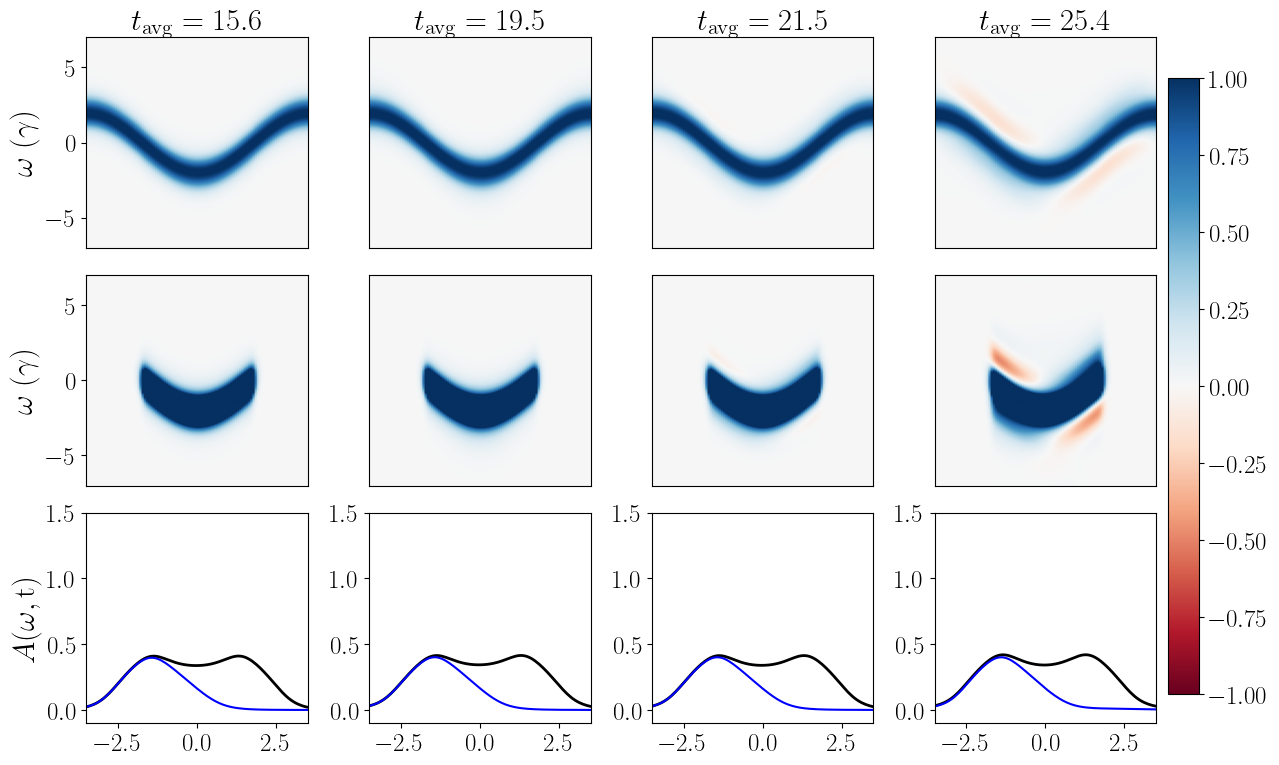

In [25]:
fig, axs = subplots(3, 4, figsize=(12, 8))

cmap = plt.get_cmap("RdBu", 3024)

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

t_avg1 = 80#200
t_avg2 = 100#200
t_avg3 = 110#20
t_avg4 = 135#30


datt1 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg1]))
datt2 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg2]))
datt3 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg3]))
datt4 = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg4]))

datt5 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg1]))
datt6 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg2]))
datt7 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg3]))
datt8 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg4]))

img1 = axs[1,1].imshow(datt1, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img2 = axs[1,2].imshow(datt2, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img3 = axs[1,3].imshow(datt3, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img4 = axs[1,4].imshow(datt4, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)

img5 = axs[2,1].imshow(datt5, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img6 = axs[2,2].imshow(datt6, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img7 = axs[2,3].imshow(datt7, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)
img8 = axs[2,4].imshow(datt8, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-1.0, vmax=1.0)

axs[1,1].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg1], digits=1))\$")
axs[1,2].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg2], digits=1))\$")
axs[1,3].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg3], digits=1))\$")
axs[1,4].set_title("\$t_{\\text{avg}} = $(round(tavg[t_avg4], digits=1))\$")

axs[1,1].set_xticks([])
axs[1,2].set_xticks([])
axs[1,3].set_xticks([])
axs[1,4].set_xticks([])

axs[2,1].set_xticks([])
axs[2,2].set_xticks([])
axs[2,3].set_xticks([])
axs[2,4].set_xticks([])

axs[1,2].set_yticks([])
axs[1,3].set_yticks([])
axs[1,4].set_yticks([])
axs[2,2].set_yticks([])
axs[2,3].set_yticks([])
axs[2,4].set_yticks([])


axs[3,1].plot(ωs, real.(A_Wigner_sumk[:,t_avg1]), color="black", linewidth=2)
axs[3,1].plot(ωs, imag.(GL_Wigner_sumk[:,t_avg1])/pi, color="blue", linewidth=1.5)


axs[3,2].plot(ωs, real.(A_Wigner_sumk[:,t_avg2]), color="black", linewidth=2)
axs[3,2].plot(ωs, imag.(GL_Wigner_sumk[:,t_avg2])/pi, color="blue", linewidth=1.5)

axs[3,3].plot(ωs, real.(A_Wigner_sumk[:,t_avg3]), color="black", linewidth=2)
axs[3,3].plot(ωs, imag.(GL_Wigner_sumk[:,t_avg3])/pi, color="blue", linewidth=1.5)


axs[3,4].plot(ωs, real.(A_Wigner_sumk[:,t_avg4]), color="black", linewidth=2)
axs[3,4].plot(ωs, imag.(GL_Wigner_sumk[:,t_avg4])/pi, color="blue", linewidth=1.5)

# axs[3,1].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# axs[3,2].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# axs[3,3].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# axs[3,4].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
# axs[3,1].set_xlabel(raw"$k$")
# axs[3,2].set_xlabel(raw"$k$")
# axs[3,3].set_xlabel(raw"$k$")
# axs[3,4].set_xlabel(raw"$k$")

axs[1,1].set_ylabel(raw"$\mathrm{\omega \; (\gamma) }$")
axs[2,1].set_ylabel(raw"$\mathrm{\omega \; (\gamma) }$")
axs[3,1].set_ylabel(raw"$A\mathrm{ (\omega, t) }$")
for ax in vec(axs)
    ax.set_ylim(-7,7)  
end
axs[3,1].set_xlim(-3.5,3.5)
axs[3,1].set_ylim(-0.1,1.5)

axs[3,2].set_xlim(-3.5,3.5)
axs[3,2].set_ylim(-0.1,1.5)

axs[3,3].set_xlim(-3.5,3.5)
axs[3,3].set_ylim(-0.1,1.5)

axs[3,4].set_xlim(-3.5,3.5)
axs[3,4].set_ylim(-0.1,1.5)


fig.subplots_adjust(right=1.14)    # mueve toda la grilla a la izquierda
fig.colorbar(img1, ax=vec(axs), location="right", pad=0.10)
fig.tight_layout()
#plt.savefig("fig1.png")

In [236]:
#### Stored data for  figures
#t_avg = 80#300
#tmax = 40.0#100
#L = 40.0#100
#datt_11 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/38.21) <- closed-rice mele
# A_11 = real.(A_Wigner_sumk[:,t_avg])/38.21
# GL_11 =  imag.(GL_Wigner_sumk[:,t_avg])/pi/(38.21)
# ks_11 = ks
# ωs_11 = ωs

# t_avg = 90
# datt_12 = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/25.15) #<- closed-chain
# A_12 = real.(A_Wigner_sumk[:,t_avg])/25.15
# GL_12 =  imag.(GL_Wigner_sumk[:,t_avg])/pi/(25.15)
# ks_12 = ks
# ωs_12 = ωs


-6.558074664368763:0.07807231743296146:6.480002346935801